# Microfinance Loan Default Prediction

## 1. Problem Statement

Microfinance institutions and mobile-money lenders in Zimbabwe (e.g., EcoCash-linked 
micro-loans) face high default rates because loan approval decisions are typically made 
using blunt, manual rule-based criteria (fixed income thresholds, collateral checks) 
that fail to capture the complex, interacting behavioural and transactional patterns 
that actually predict repayment behaviour. Poor risk assessment restricts credit access 
for genuinely low-risk borrowers while exposing lenders to losses from high-risk ones  
a problem with direct consequences for financial inclusion in Zimbabwe's largely 
mobile-money-driven economy.

## 2. ML Problem Type

Supervised **classification**.

## 3. Target Variable

Loan outcome — binary (`Defaulted` / `Repaid`).

## 4. Why Machine Learning, Not a Rule-Based Approach

Default risk depends on the interaction of multiple variables like repayment history, 
loan-to-income ratio, transaction frequency, loan size, employment status rather than 
any single threshold. A fixed rule (e.g., "income > $X") cannot model these interactions 
or adapt as patterns shift, and treats all applicants above/below the cutoff identically 
regardless of other risk signals. A trained classifier can learn non-linear relationships 
between features and default likelihood, weight multiple factors simultaneously, and be 
evaluated/tuned against real cost trade-offs (false negatives = losses, false positives = 
excluded good borrowers) — something a static rule cannot do.

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

In [2]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\User
['.anaconda', '.android', '.arduinoIDE', '.bob', '.bobide', '.cache', '.codex', '.conda', '.config', '.continuum', '.copilot', '.cursor', '.dotnet', '.emulator_console_auth_token', '.gitconfig', '.gradle', '.idea', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.ms-ad', '.nbi', '.node_repl_history', '.npmrc', '.oracle_jre_usage', '.packettracer', '.python_history', '.templateengine', '.virtual_documents', '.vscode', '.vscode-shared', '3D Objects', 'anaconda3', 'AndroidStudioProjects', 'AppData', 'Application Data', 'attentance.mdb', 'Cisco Packet Tracer 9.0.0', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'gzu-blockchain-voting-system', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'main.ipynb', 'Microfinance-loan-default-prediction', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.0.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-0

In [3]:
os.listdir('Microfinance-loan-default-prediction')

['.ipynb_checkpoints',
 'cs-test.csv',
 'cs-training.csv',
 'Data Dictionary.xls',
 'sampleEntry.csv']

In [4]:
import pandas as pd
df = pd.read_csv('Microfinance-loan-default-prediction/cs-training.csv')
df.shape

(150000, 12)

In [5]:
df.shape 

(150000, 12)

In [6]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Data Source & Ethical Considerations

**Source:** "Give Me Some Credit" dataset (Kaggle), originally compiled for a U.S. 
credit-risk modelling competition. Publicly available, anonymised, and contains no 
personally identifiable information (PII).

**Size:** [ 150,000 rows, 12 columns]

**Why this dataset:** Real loan-book data from Zimbabwean microfinance institutions 
or mobile-money lenders was not accessible for this project. This dataset is used 
as a *methodological proxy* this  allows the full ML pipeline (cleaning, EDA, feature 
engineering, model training, evaluation) to be demonstrated on realistic credit-risk 
data with a comparable feature structure (income, debt ratio, repayment history, 
dependents).

**Limitation:** Because the data originates from a different country/context, the 
specific patterns and model performance found here should not be assumed to transfer 
directly to Zimbabwean borrowers. In a real deployment, the same pipeline would need 
to be retrained on local data before being trusted for actual lending decisions.

**Privacy:** All records are anonymised with no names, ID numbers, or other PII(Personal Identity information), so 
no additional data protection concerns apply beyond standard dataset licensing terms.

In [7]:
df = pd.read_csv('Microfinance-loan-default-prediction/cs-training.csv')


In [8]:
df.shape


(150000, 12)

In [9]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [10]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [11]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [12]:
df.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [13]:
print(df.columns.tolist())

['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [14]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [15]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

In [16]:
df.isnull().sum()


Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [17]:
df['age'].describe()


count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

In [18]:
df[['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']].describe()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
count,150000.000000,150000.000000,150000.000000
mean,0.421033,0.265973,0.240387
std,4.192781,4.169304,4.155179
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,98.000000,98.000000,98.000000


In [19]:
# Remove invalid age
df = df[df['age'] > 0]

# Cap the error-code values in past-due columns
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']:
    median_val = df.loc[df[col] < 90, col].median()
    df.loc[df[col] > 90, col] = median_val

In [20]:
df['age'].describe()
df[['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']].describe()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
count,149999.000000,149999.000000,149999.000000
mean,0.245348,0.090294,0.064707
std,0.697231,0.485108,0.329790
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,13.000000,17.000000,11.000000


In [21]:
df.dtypes

Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(119999, 11) (30000, 11)
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


## 3. Data Cleaning & Preparation

**Missing values:** `MonthlyIncome` (29,731 missing, ~19.8%) was filled with the median, 
which is robust to the outliers common in income data. `NumberOfDependents` (3,924 
missing, ~2.6%) was filled with 0, a reasonable default for a count variable.

**Invalid values:** Records with `age = 0` were removed, as this is not a valid age. 
The three past-due columns (`NumberOfTime30-59DaysPastDueNotWorse`, 
`NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`) contained a known 
data-entry error code of 98, which was replaced with the column median.

**Encoding:** all features are numeric (`int64`/`float64`), with no 
categorical variables to encode.

**Train/test split:** Data was split 80/20 (119,999 train / 30,000 test rows), stratified 
on the target variable to preserve the class distribution. The dataset is imbalanced 
only ~6.7% of borrowers defaulted  which will be accounted for in model evaluation 
(accuracy alone would be misleading; precision, recall, and F1 will be prioritized).

In [24]:
!pip install seaborn

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

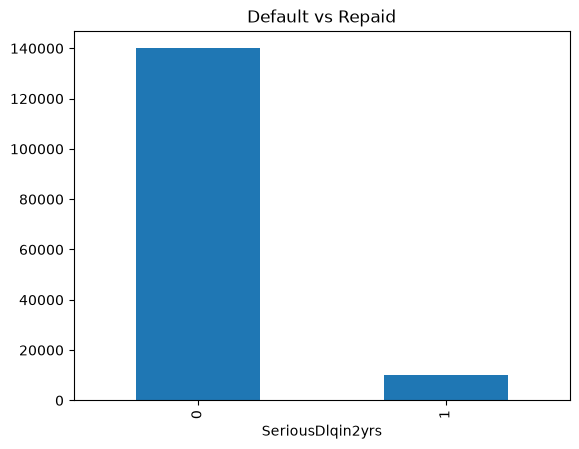

In [26]:
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', title='Default vs Repaid');
plt.show()

**Interpretation:** The dataset is highly imbalanced, with approximately 93% of customers repaid and only 7% experiencing serious delinquency.

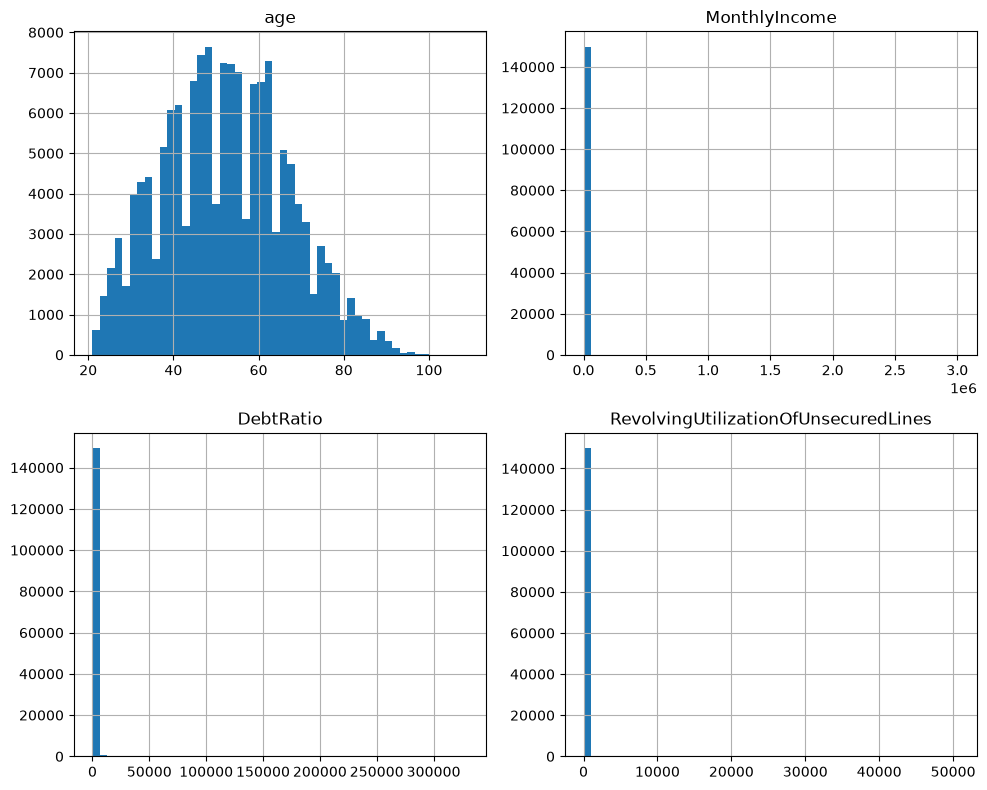

In [27]:
df[['age', 'MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']].hist(figsize=(10,8), bins=50); plt.tight_layout();
plt.show()

**Interpretation:** Age is relatively concentrated, while MonthlyIncome, DebtRatio, and RevolvingUtilizationOfUnsecuredLines are strongly right-skewed with a small number of extreme values.

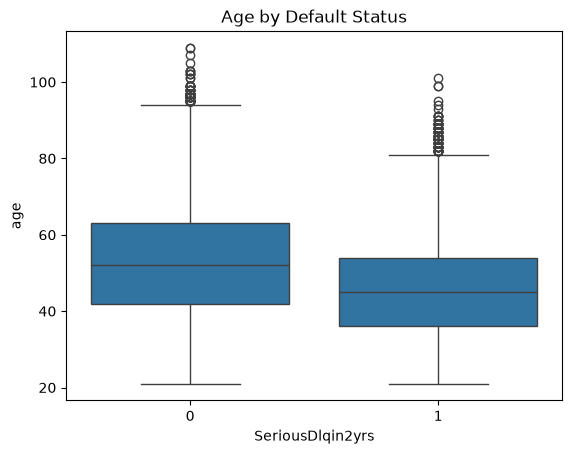

In [28]:
sns.boxplot(data=df, x='SeriousDlqin2yrs', y='age');
plt.title('Age by Default Status');
plt.show()

**Interpretation:** The age distributions of defaulters and non-defaulters overlap substantially, although the median ages show some difference between the two groups.

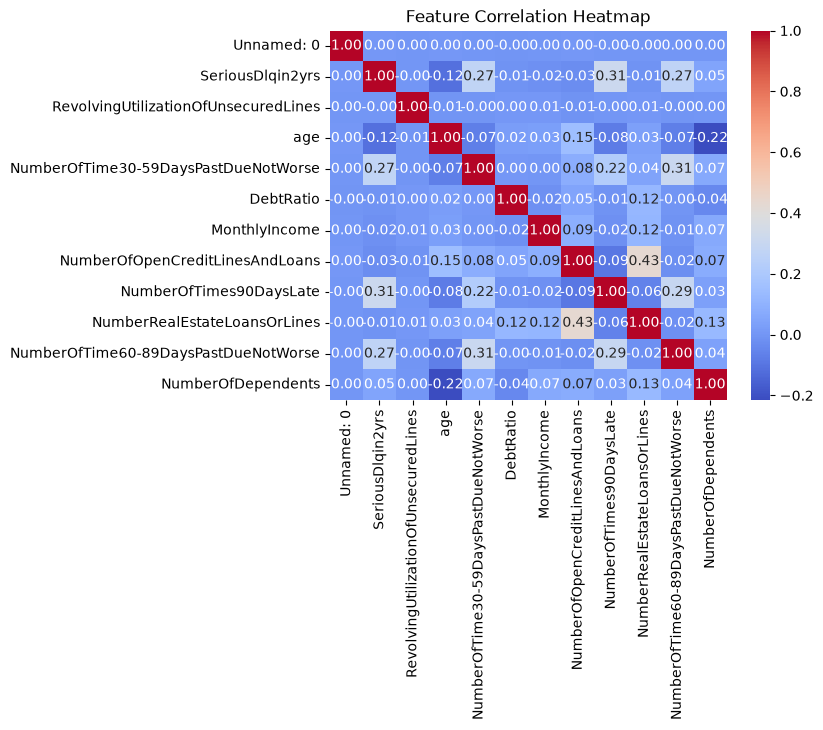

In [29]:
corr = df.corr();
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm');
plt.title('Feature Correlation Heatmap'); 
plt.show()

**Interpretation:** The heatmap shows generally weak correlations between most features, with some variables showing stronger relationships with the target and with each other.

## Summary

The exploratory data analysis shows that the target variable is highly imbalanced, with approximately 93% of customers repaid and 7% experiencing serious delinquency. The feature distributions reveal strong skewness and extreme outliers, particularly in MonthlyIncome, DebtRatio, and RevolvingUtilizationOfUnsecuredLines. The boxplots show differences between defaulters and non-defaulters, although there is considerable overlap between the groups. The correlation heatmap indicates that most features have relatively weak linear relationships with the target. These findings suggest that age, income, debt ratio, credit utilization, and other relevant financial features should be prioritized during feature engineering, while skewed variables and extreme outliers should be carefully handled.

In [30]:


df['TotalPastDue'] = df['NumberOfTime30-59DaysPastDueNotWorse'] + df['NumberOfTime60-89DaysPastDueNotWorse'] + df['NumberOfTimes90DaysLate']

In [31]:
df['TotalPastDue'].describe()

count    149999.000000
mean          0.400349
std           1.101292
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          19.000000
Name: TotalPastDue, dtype: float64

In [32]:
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

In [33]:
df['IncomePerDependent'].describe()

count    1.499990e+05
mean     4.589136e+03
std      7.974517e+03
min      0.000000e+00
25%      2.151000e+03
50%      4.000000e+03
75%      5.400000e+03
max      1.794060e+06
Name: IncomePerDependent, dtype: float64

In [34]:
df['AgeGroup'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100], labels=['<25','25-34','35-44','45-54','55-64','65+'])
df['AgeGroup'] = df['AgeGroup'].cat.codes

In [35]:
df['AgeGroup'].value_counts()


AgeGroup
 3    36690
 4    33406
 2    29819
 5    28586
 1    18458
 0     3027
-1       13
Name: count, dtype: int64

In [36]:
import numpy as np

In [37]:
df['LogMonthlyIncome'] = np.log1p(df['MonthlyIncome'])
df['LogDebtRatio'] = np.log1p(df['DebtRatio'])

In [38]:
df[['LogMonthlyIncome', 'LogDebtRatio']].describe()

,LogMonthlyIncome,LogDebtRatio
count,149999.000000,149999.000000
mean,8.447403,1.525182
std,1.195800,2.627244
min,0.000000,0.000000
25%,8.269757,0.161331
50%,8.594339,0.312255
75%,8.909370,0.625006
max,14.917036,12.705832


In [39]:
df = df.drop(columns=['MonthlyIncome', 'DebtRatio'])
df.columns.tolist()


['Unnamed: 0',
 'SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'TotalPastDue',
 'IncomePerDependent',
 'AgeGroup',
 'LogMonthlyIncome',
 'LogDebtRatio']

In [40]:
df = df.drop(columns=['Unnamed: 0'])

In [41]:
df.columns.tolist()



['SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'TotalPastDue',
 'IncomePerDependent',
 'AgeGroup',
 'LogMonthlyIncome',
 'LogDebtRatio']

In [42]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(119999, 13) (30000, 13)


## 5. Feature Engineering

- **TotalPastDue:** Sum of all three past-due columns, consolidating payment history 
  into a single, stronger risk signal.
- **IncomePerDependent:** Monthly income divided by number of dependents (+1 to avoid 
  division by zero), capturing financial burden per household member rather than raw income alone.
- **AgeGroup:** Age binned into six bands and encoded numerically, to capture potential 
  non-linear relationships between age and default risk that a raw continuous value might miss.
- **LogMonthlyIncome / LogDebtRatio:** Log-transformed versions of the heavily right-skewed 
  income and debt-ratio features, reducing the influence of extreme outliers. The raw 
  versions were dropped to avoid redundancy.

The dataset now has 13 features (up from the original 10), and the train/test split was 
re-run on the final feature set: 119,999 training rows, 30,000 test rows.

In [43]:
import os
print(os.getcwd())

C:\Users\User
